# Validation 1: Structural model quality

Peptide-backbone RMSD between FlexPepDock decoys and experimental crystal structures, for the subset of peptide–allele pairs that have a matching experimental structure in our local HLA crystal structure database (`/home/huntek1/Data/MHC_database/`).

Three metrics per pair:
1. RMSD of the lowest-`total_score` decoy.
2. Mean RMSD across the five lowest-scoring decoys.
3. Lowest RMSD across all 25 decoys.

Outputs: `rmsd_per_pair.csv`, `summary_statistics.json`, `figure2_rmsd_distributions.{png,pdf}` in `IEDB_validation/01_structural/`.

## Setup

In [18]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Make the local utils package importable
sys.path.insert(0, str(Path.cwd()))
from utils import (
    allele_to_dir_name,
    get_decoy_paths,
    get_experimental_pdb,
    load_metadata,
    load_structure,
    set_plot_style)
from utils.structure import (
    superpose_on_mhc,
    peptide_backbone_atoms)

set_plot_style()

In [19]:
# === Paths (edit if your layout differs) ===
HF_DIR        = Path('/home/huntek1/main_project/data/IEDB_data_clean/huggingface')
PDB_ROOT = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/regeneration/pdb')
MHC_DB_DIR    = Path('/home/huntek1/Data/MHC_database')
TEMPLATE_DIR  = MHC_DB_DIR / 'templates'
OUT_DIR = Path('/home/huntek1/main_project/data/IEDB_data_clean/IEDB_validation/01_structural_regen')
CACHE_DIR     = OUT_DIR / 'intermediate' / 'experimental_pdbs'

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Column names in metadata.csv
COL_ALLELE  = 'allele'
COL_PEPTIDE = 'peptide'
COL_FLAGGED = 'flagged'

## Match dataset entries to the local HLA crystal-structure database

The dataset's `assay_pdb_id` column was not populated by the curation pipeline. We instead match each (peptide, allele) pair against the local MHC structure database, which was assembled from IEDB-deposited HLA class I crystal structures and contains the cleaned PDBs plus explicit chain-ID annotations.

Note on validity: the threading pipeline (`get_peptide_template` in `HLA_db.py`) explicitly excludes self-matches when selecting templates, so an experimental structure for (peptide X, allele Y) is *not* used as the threading template for that pair. The experimental structures are therefore independent references for validation.

In [20]:
mhc_db = pd.read_csv(MHC_DB_DIR / 'database.info')
print(f'Local MHC database: {len(mhc_db):,} structures')

metadata = load_metadata(HF_DIR / 'metadata.csv')
print(f'Total dataset pairs: {len(metadata):,}')

Local MHC database: 566 structures
Total dataset pairs: 49,488


In [21]:
# Match (allele, peptide) against the local DB
metadata_for_match = metadata[~metadata[COL_FLAGGED].astype(bool)].copy()

merged = metadata_for_match.merge(
    mhc_db[['MHC_Allele', 'Epitope_Description', 'PDB_ID',
            'MHC_PDB_Chain1', 'Antigen_PDB_Chain(s)',
            'Resolution_(Angstrom)']]
    .rename(columns={
        'MHC_Allele':            COL_ALLELE,
        'Epitope_Description':   COL_PEPTIDE,
        'PDB_ID':                'matched_pdb_id',
        'MHC_PDB_Chain1':        'mhc_chain_id',
        'Antigen_PDB_Chain(s)':  'peptide_chain_id',
        'Resolution_(Angstrom)': 'resolution_angstrom',
    }),
    on=[COL_ALLELE, COL_PEPTIDE],
    how='inner',
)

# Where a pair has multiple PDBs, keep the highest-resolution one
merged['resolution_angstrom'] = pd.to_numeric(
    merged['resolution_angstrom'], errors='coerce'
)
subset = (
    merged
    .sort_values('resolution_angstrom', ascending=True)
    .drop_duplicates(subset=[COL_ALLELE, COL_PEPTIDE], keep='first')
    .reset_index(drop=True)
)

print(f'Pairs with experimental match: {len(subset):,}')
print(f'Median resolution: {subset["resolution_angstrom"].median():.2f} Å')
print(f'Resolution range:  {subset["resolution_angstrom"].min():.2f} – '
      f'{subset["resolution_angstrom"].max():.2f} Å')

subset[[COL_ALLELE, COL_PEPTIDE, 'matched_pdb_id', 'mhc_chain_id',
        'peptide_chain_id', 'resolution_angstrom']].head()

Pairs with experimental match: 52
Median resolution: 1.90 Å
Resolution range:  1.10 – 3.00 Å


,allele,peptide,matched_pdb_id,mhc_chain_id,peptide_chain_id,resolution_angstrom
0,A*02:01,GLCTLVAML,3MRE,A,P,1.1
1,A*02:01,CINGVCWTV,3MRG,A,P,1.3
2,A*02:01,VLHDDLLEA,3D25,A,C,1.3
3,A*02:01,GILGFVFTL,1OGA,A,C,1.4
4,A*02:01,GMSRIGMEV,7KGP,A,C,1.4


## Compute RMSD metrics per pair

For each pair, sort the 25 decoys by `total_score`, superpose the modeled MHC binding cleft onto the experimental MHC, apply the rotation to the modeled peptide, and compute peptide-backbone (N, Cα, C, O) RMSD. Three summary metrics per pair: best-score decoy, mean of top-5 by score, and minimum across all 25.

We use the explicit chain IDs from `database.info` for the experimental structures, avoiding any chain-identification heuristic. Modeled structures use the project convention (chain A = MHC, chain B = peptide).

In [22]:
from utils.structure import chain_sequence

def find_peptide_chain_in_modeled(struct, expected_peptide):
    """Find the modeled chain matching the expected peptide sequence."""
    for chain in struct[0]:
        if chain_sequence(chain) == expected_peptide:
            return chain
    # Fallback to chain B for backward compatibility
    return struct[0]['B']


def find_mhc_chain_in_modeled(struct, peptide_chain_id):
    """Find the MHC chain (longest non-peptide protein chain)."""
    candidates = [
        c for c in struct[0]
        if c.id != peptide_chain_id and len(chain_sequence(c)) >= 100
    ]
    if not candidates:
        raise ValueError(f"No MHC chain found in {struct.id}")
    return max(candidates, key=lambda c: len(chain_sequence(c)))


def compute_metrics_for_pair(allele, peptide, pdb_id,
                             mhc_chain_id, peptide_chain_id):
    """Compute three RMSD metrics for one peptide–allele pair."""
    allele_dir = allele_to_dir_name(allele)
    _, decoy_paths, score_df = get_decoy_paths(PDB_ROOT, allele_dir, peptide)

    # Sort decoys by total_score (best first)
    order = np.argsort(score_df['total_score'].values)
    decoy_paths = [decoy_paths[i] for i in order]
    scores = score_df['total_score'].values[order]

    # Load the experimental structure once
    exp_pdb = get_experimental_pdb(pdb_id, TEMPLATE_DIR, CACHE_DIR)
    exp_struct = load_structure(exp_pdb)

    # Antigen chain field may list multiple chains (e.g. 'C, F'); take first
    pep_chain_id = str(peptide_chain_id).split(',')[0].strip()
    exp_pep = exp_struct[0][pep_chain_id]
    exp_mhc = exp_struct[0][str(mhc_chain_id).strip()]

    rmsds = []
    last_mhc_rmsd = None
    for decoy in decoy_paths:
        mod_struct = load_structure(decoy)
        mod_pep = find_peptide_chain_in_modeled(mod_struct, peptide)
        mod_mhc = find_mhc_chain_in_modeled(mod_struct, mod_pep.id)

        sup, mhc_rmsd = superpose_on_mhc(mod_mhc, exp_mhc, n_residues=180)
        sup.apply(list(mod_struct.get_atoms()))
        last_mhc_rmsd = mhc_rmsd

        mod_atoms = peptide_backbone_atoms(mod_pep)
        exp_atoms = peptide_backbone_atoms(exp_pep)
        n = min(len(mod_atoms), len(exp_atoms))
        if n == 0:
            raise ValueError('No peptide backbone atoms to compare')
        diffs = np.array(
            [mod_atoms[i].coord - exp_atoms[i].coord for i in range(n)]
        )
        rmsds.append(float(np.sqrt(np.mean(np.sum(diffs ** 2, axis=1)))))
    rmsds = np.array(rmsds)

    return {
        'rmsd_best_score':    float(rmsds[0]),
        'rmsd_top5_mean':     float(rmsds[:5].mean()),
        'rmsd_min_of_25':     float(rmsds.min()),
        'best_score':         float(scores[0]),
        'n_decoys':           int(len(rmsds)),
        'mhc_alignment_rmsd': float(last_mhc_rmsd),
    }

In [23]:
results = []
errors  = []
for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Pairs'):
    try:
        m = compute_metrics_for_pair(
            allele=row[COL_ALLELE],
            peptide=row[COL_PEPTIDE],
            pdb_id=row['matched_pdb_id'],
            mhc_chain_id=row['mhc_chain_id'],
            peptide_chain_id=row['peptide_chain_id'],
        )
        results.append({**row.to_dict(), **m})
    except Exception as e:
        errors.append({
            COL_ALLELE:  row[COL_ALLELE],
            COL_PEPTIDE: row[COL_PEPTIDE],
            'pdb_id':    row['matched_pdb_id'],
            'error':     f'{type(e).__name__}: {e}',
        })

rmsd_df  = pd.DataFrame(results)
error_df = pd.DataFrame(errors)

print(f'Successful: {len(rmsd_df)} / {len(subset)}')
if len(error_df) > 0:
    print(f'Failed:     {len(error_df)}')
    print('\nError type breakdown:')
    print(error_df['error'].str.split(':').str[0].value_counts())

Pairs:   0%|          | 0/52 [00:00<?, ?it/s]

Successful: 52 / 52


In [24]:
# Save per-pair results and any errors
rmsd_df.to_csv(OUT_DIR / 'rmsd_per_pair.csv', index=False)
if len(error_df) > 0:
    error_df.to_csv(OUT_DIR / 'rmsd_errors.csv', index=False)

rmsd_df.head()

,allele_iedb,allele,peptide,peptide_length,measurement_type,measurement_value,measurement_units,assay_method,assay_response,pubmed_id,...,matched_pdb_id,mhc_chain_id,peptide_chain_id,resolution_angstrom,rmsd_best_score,rmsd_top5_mean,rmsd_min_of_25,best_score,n_decoys,mhc_alignment_rmsd
0,HLA-A_02_01,A*02:01,GLCTLVAML,9,Kd,59.0,nM,purified MHC/competitive/fluorescence,dissociation constant (KD),NaN,...,3MRE,A,P,1.1,1.329920,1.278205,1.018367,-577.701,25,0.673152
1,HLA-A_02_01,A*02:01,CINGVCWTV,9,IC50,50000.0,nM,purified MHC/competitive/fluorescence,half maximal inhibitory concentration (IC50),24721533.0,...,3MRG,A,P,1.3,1.105160,1.049377,0.761388,-558.973,25,0.766225
2,HLA-A_02_01,A*02:01,VLHDDLLEA,9,IC50,30.0,nM,purified MHC/competitive/fluorescence,half maximal inhibitory concentration (IC50),9461441.0,...,3D25,A,C,1.3,0.890997,0.992227,0.888823,-555.213,25,0.751287
3,HLA-A_02_01,A*02:01,GILGFVFTL,9,IC50,30.0,nM,purified MHC/competitive/fluorescence,half maximal inhibitory concentration (IC50),7539551.0,...,1OGA,A,C,1.4,1.471087,1.304458,0.807369,-532.897,25,0.766868
4,HLA-A_02_01,A*02:01,GMSRIGMEV,9,Kd,1.6,nM,purified MHC/competitive/fluorescence,dissociation constant (KD),NaN,...,7KGP,A,C,1.4,1.132480,1.114465,1.048523,-562.001,25,0.733740


## Summary statistics

In [25]:
def summarise(values: np.ndarray) -> dict:
    return {
        'n':        int(len(values)),
        'median':   float(np.median(values)),
        'q1':       float(np.quantile(values, 0.25)),
        'q3':       float(np.quantile(values, 0.75)),
        'mean':     float(values.mean()),
        'pct_lt_2': float((values < 2.0).mean() * 100),
        'pct_lt_3': float((values < 3.0).mean() * 100),
    }

summary = {
    'rmsd_best_score':    summarise(rmsd_df['rmsd_best_score'].values),
    'rmsd_top5_mean':     summarise(rmsd_df['rmsd_top5_mean'].values),
    'rmsd_min_of_25':     summarise(rmsd_df['rmsd_min_of_25'].values),
    'mhc_alignment_rmsd': summarise(rmsd_df['mhc_alignment_rmsd'].values),
    'n_pairs_attempted':  int(len(subset)),
    'n_pairs_succeeded':  int(len(rmsd_df)),
    'n_pairs_failed':     int(len(error_df)),
}

with open(OUT_DIR / 'summary_statistics.json', 'w') as f:
    json.dump(summary, f, indent=2)

for k, v in summary.items():
    print(k)
    print(' ', v)

rmsd_best_score
  {'n': 52, 'median': 1.1554964780807495, 'q1': 0.8869049698114395, 'q3': 1.4473633468151093, 'mean': 1.2735202037371123, 'pct_lt_2': 86.53846153846155, 'pct_lt_3': 96.15384615384616}
rmsd_top5_mean
  {'n': 52, 'median': 1.1453582227230072, 'q1': 0.8480612307786941, 'q3': 1.4726877152919768, 'mean': 1.2859716410820299, 'pct_lt_2': 88.46153846153845, 'pct_lt_3': 98.07692307692307}
rmsd_min_of_25
  {'n': 52, 'median': 0.9237312972545624, 'q1': 0.7025244385004044, 'q3': 1.3282462656497955, 'mean': 1.0924378432906592, 'pct_lt_2': 92.3076923076923, 'pct_lt_3': 100.0}
mhc_alignment_rmsd
  {'n': 52, 'median': 0.7448361557621084, 'q1': 0.6798346698512884, 'q3': 0.8101381602192449, 'mean': 0.82341121190928, 'pct_lt_2': 98.07692307692307, 'pct_lt_3': 100.0}
n_pairs_attempted
  52
n_pairs_succeeded
  52
n_pairs_failed
  0


## Figure 2: RMSD distributions

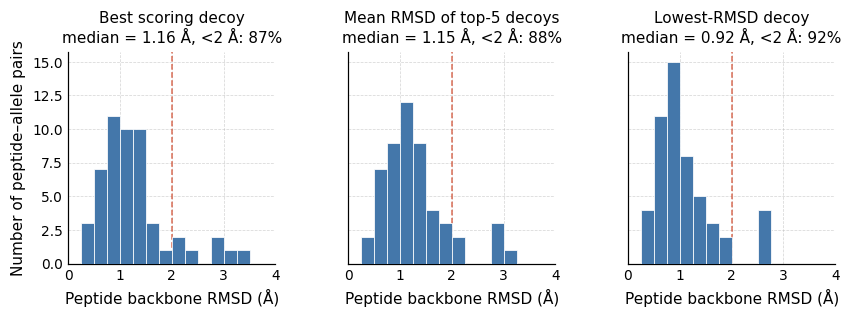

In [26]:
plt.rcParams.update({'font.size': 10})

metrics = [
    ('rmsd_best_score', 'Best scoring decoy'),
    ('rmsd_top5_mean',  'Mean RMSD of top-5 decoys'),
    ('rmsd_min_of_25',  'Lowest-RMSD decoy')]

bins = np.arange(0, 10.1, 0.25)
fig, axes = plt.subplots(1, 3, figsize=(9, 2.5), sharey=True, gridspec_kw={'wspace': 0.35})

for ax, (col, label) in zip(axes, metrics):
    vals = rmsd_df[col].values
    ax.hist(vals, bins=bins, color='#4477AA', edgecolor='white', linewidth=0.5, zorder=3)
    ax.axvline(2.0, color='#CC3311', linestyle='--', linewidth=1, alpha=0.7)

    # Background grid
    ax.grid(True, which='major', axis='both',
            linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

    # Remove tick marks (the little lines)
    ax.tick_params(axis='both', which='both', length=0)

    ax.set_title(f'{label}\nmedian = {np.median(vals):.2f} Å, 'f'<2 Å: {(vals < 2).mean()*100:.0f}%', fontsize=10)

    ax.set_xlabel('Peptide backbone RMSD (Å)', fontsize=10)
    ax.set_xlim(0, 4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Number of peptide–allele pairs', fontsize=10)

fig.savefig(OUT_DIR / 'rmsd_distributions.png')
fig.savefig(OUT_DIR / 'rmsd_distributions.pdf')

plt.show()

## Stratified analysis (optional): RMSD by peptide length

In [27]:
rmsd_df['peptide_length'] = rmsd_df[COL_PEPTIDE].str.len()
by_length = (
    rmsd_df
    .groupby('peptide_length')['rmsd_best_score']
    .agg(['count', 'median', 'mean'])
    .reset_index()
)
by_length

,peptide_length,count,median,mean
0,8,1,0.974463,0.974463
1,9,40,1.121824,1.142839
2,10,9,1.296942,1.517308
3,11,1,2.847861,2.847861
4,12,1,3.031401,3.031401


## Template-similarity analysis

Tests whether validation RMSD depends on how similar the threading template was to the native peptide. 
Templates are recovered by replicating the `get_peptide_template` logic from `HLA_db.py`: 
for each native peptide, pick the same-length, same-allele template from `database.info` with the highest 
BLOSUM62 alignment score against the native, excluding exact-sequence self-matches.

In [28]:
from Bio.Align import substitution_matrices
from Bio import pairwise2

matrix = substitution_matrices.load("BLOSUM62")

def best_template_for_pair(allele, peptide, mhc_db_info, exclude_self=True):
    """Mimic HLA_db.get_peptide_template: pick the best same-length, same-allele
    template peptide by BLOSUM62 similarity, excluding exact self-matches.
    Returns (template_pdb_id, template_peptide_seq, percent_identity)."""
    candidates = mhc_db_info[
        (mhc_db_info['MHC_Allele'] == allele) &
        (mhc_db_info['Epitope_Description'].str.len() == len(peptide))
    ].copy()
    if exclude_self:
        candidates = candidates[candidates['Epitope_Description'] != peptide]
    if len(candidates) == 0:
        return None, None, None

    best_score = -float('inf')
    best_row = None
    for _, row in candidates.iterrows():
        cand_seq = row['Epitope_Description']
        alignments = pairwise2.align.globalds(peptide, cand_seq, matrix, -10, -0.5)
        score = max(a.score for a in alignments)
        if score > best_score:
            best_score = score
            best_row = row

    template_seq = best_row['Epitope_Description']
    identity = sum(a == b for a, b in zip(peptide, template_seq)) / len(peptide) * 100
    return best_row['PDB_ID'], template_seq, identity


# Compute template identity for each validation pair
template_info = []
for _, row in rmsd_df.iterrows():
    pdb, seq, ident = best_template_for_pair(
        row[COL_ALLELE], row[COL_PEPTIDE], mhc_db
    )
    template_info.append({
        'template_pdb':       pdb,
        'template_peptide':   seq,
        'template_identity':  ident,
    })

template_df = pd.DataFrame(template_info)
rmsd_df = pd.concat([rmsd_df.reset_index(drop=True), template_df], axis=1)

print('Template identity distribution:')
print(rmsd_df['template_identity'].describe())
print()
print('Pairs by identity bracket:')
print(pd.cut(rmsd_df['template_identity'],
             bins=[0, 50, 70, 85, 95, 100],
             include_lowest=True).value_counts().sort_index())

Template identity distribution:
count    50.000000
mean     54.119192
std      29.259505
min       0.000000
25%      30.833333
50%      44.444444
75%      88.888889
max      90.000000
Name: template_identity, dtype: float64

Pairs by identity bracket:
template_identity
(-0.001, 50.0]    26
(50.0, 70.0]       6
(70.0, 85.0]       1
(85.0, 95.0]      17
(95.0, 100.0]      0
Name: count, dtype: int64


In [29]:
# Compute template identity for each validation pair
template_info = []
for _, row in rmsd_df.iterrows():
    pdb, seq, ident = best_template_for_pair(
        row[COL_ALLELE], row[COL_PEPTIDE], mhc_db
    )
    template_info.append({
        'template_pdb':      pdb,
        'template_peptide':  seq,
        'template_identity': ident,
    })

# Drop any pre-existing template columns so this cell is safe to re-run
rmsd_df = rmsd_df.drop(
    columns=['template_pdb', 'template_peptide', 'template_identity'],
    errors='ignore',
)

template_df = pd.DataFrame(template_info)
rmsd_df = pd.concat([rmsd_df.reset_index(drop=True), template_df], axis=1)

print(f'Template identity computed. Range: '
      f'{rmsd_df["template_identity"].min():.1f}% – '
      f'{rmsd_df["template_identity"].max():.1f}%')

Template identity computed. Range: 0.0% – 90.0%


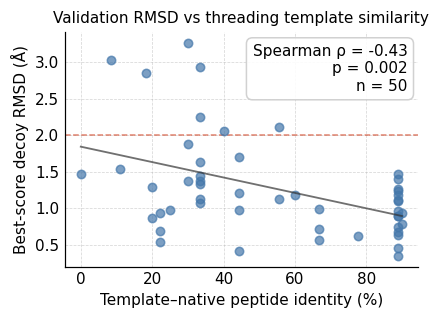

In [30]:
from scipy.stats import spearmanr

FONT_SIZE = 10

# Compute the correlation for annotation
valid = rmsd_df.dropna(subset=['template_identity', 'rmsd_best_score'])
rho_result = spearmanr(valid['template_identity'], valid['rmsd_best_score'])
rho, pval, n = rho_result.statistic, rho_result.pvalue, len(valid)

# Format p-value
if pval < 0.001:
    p_str = 'p < 0.001'
else:
    p_str = f'p = {pval:.3f}'

fig, ax = plt.subplots(figsize=(4, 3))

ax.scatter(valid['template_identity'], valid['rmsd_best_score'], alpha=0.7, s=30, color='#4477AA', zorder=3)

# Linear trendline
x = valid['template_identity'].values
y = valid['rmsd_best_score'].values
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([x.min(), x.max()])

ax.plot(x_line, slope * x_line + intercept,
    color='#333333', linestyle='-', linewidth=1.2, alpha=0.7, zorder=4)

# 2 Å reference line
ax.axhline(2.0, color='#CC3311', linestyle='--', linewidth=1, alpha=0.6, zorder=2)

# Background grid
ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

# Remove tick marks
ax.tick_params(axis='both', which='both', length=0, labelsize=FONT_SIZE)

# Annotation
ax.text(0.97, 0.95,
    f'Spearman ρ = {rho:.2f}\n{p_str}\nn = {n}',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=FONT_SIZE,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc', alpha=0.9))

# Labels and title
ax.set_xlabel('Template–native peptide identity (%)', fontsize=FONT_SIZE)
ax.set_ylabel('Best-score decoy RMSD (Å)', fontsize=FONT_SIZE)

ax.set_title(
    'Validation RMSD vs threading template similarity',
    fontsize=FONT_SIZE)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

fig.savefig(OUT_DIR / 'figure2c_rmsd_vs_template_identity.png')
fig.savefig(OUT_DIR / 'figure2c_rmsd_vs_template_identity.pdf')

plt.show()

In [31]:
from scipy.stats import spearmanr

# Using the merged dataframe from the recovery analysis or the in-line approximation
valid = rmsd_df.dropna(subset=['template_identity'])  # if column present
# or re-run template_recovery analysis against the new RMSDs

rho = spearmanr(valid['template_identity'], valid['rmsd_best_score'])
print(f'Spearman ρ(identity, RMSD): {rho.statistic:+.3f}  '
      f'(p = {rho.pvalue:.3f}, n = {len(valid)})')

Spearman ρ(identity, RMSD): -0.431  (p = 0.002, n = 50)


In [32]:
rmsd_df.to_csv(OUT_DIR / 'rmsd_per_pair.csv', index=False)
print(f'Updated rmsd_per_pair.csv now has columns: {list(rmsd_df.columns)}')

Updated rmsd_per_pair.csv now has columns: ['allele_iedb', 'allele', 'peptide', 'peptide_length', 'measurement_type', 'measurement_value', 'measurement_units', 'assay_method', 'assay_response', 'pubmed_id', 'parent_protein', 'protein_accession', 'source_organism', 'assay_pdb_id', 'flagged', 'has_structures', 'num_pdbs', 'rosetta_best_score', 'rosetta_mean_score', 'pdb_dir', 'matched_pdb_id', 'mhc_chain_id', 'peptide_chain_id', 'resolution_angstrom', 'rmsd_best_score', 'rmsd_top5_mean', 'rmsd_min_of_25', 'best_score', 'n_decoys', 'mhc_alignment_rmsd', 'template_pdb', 'template_peptide', 'template_identity']


## Outliers

Pairs whose best-score decoy RMSD exceeds 2 Å. Inspecting these helps characterize where the protocol struggles 
(typically longer peptides or pairs with distant available templates).

In [33]:
outliers = rmsd_df[rmsd_df['rmsd_best_score'] > 2.0]
print(outliers[[COL_ALLELE, COL_PEPTIDE, 'peptide_length',
                'template_identity', 'rmsd_best_score', 'rmsd_min_of_25']])

     allele       peptide  peptide_length  template_identity  rmsd_best_score  \
9   B*07:02     RPPIFIRRL               9          33.333333         2.931083   
24  A*02:01     RQASLSISV               9          55.555556         2.110837   
35  A*02:01     RQISQDVKL               9          33.333333         2.256841   
39  A*02:01    LLFNILGGWV              10          30.000000         3.264402   
48  A*02:01  RQASIELPSMAV              12           8.333333         3.031401   
49  A*24:02   LYKKLKREITF              11          18.181818         2.847861   
50  A*02:01    TLACFVLAAV              10          40.000000         2.056550   

    rmsd_min_of_25  
9         2.502151  
24        1.704759  
35        1.875823  
39        2.651942  
48        2.613982  
49        2.616744  
50        1.917569  


## Sanity check: MHC alignment quality

Confirms that the MHC superposition used for peptide RMSD calculation is well-behaved across all pairs. 
A clean alignment (median ≲ 1 Å) is required for the peptide RMSDs to be interpretable.

In [34]:
print('MHC alignment RMSD stats:')
print(rmsd_df['mhc_alignment_rmsd'].describe())

MHC alignment RMSD stats:
count    52.000000
mean      0.823411
std       0.299837
min       0.583505
25%       0.679835
50%       0.744836
75%       0.810138
max       2.005498
Name: mhc_alignment_rmsd, dtype: float64


## Peptide visualization filter

In [36]:
# ----- Shortlist candidates per tier -----
# Tier definitions (match notebook 03)
high_id   = rmsd_df[rmsd_df['template_identity'] >= 80].copy()
# Moderate-identity tier (35% < template < 80%, RMSD ≤ 2 Å)
moderate = rmsd_df[(rmsd_df['template_identity'] > 35) &
                   (rmsd_df['template_identity'] < 80) &
                   (rmsd_df['rmsd_best_score'] <= 2.0)].copy()
low_id    = rmsd_df[(rmsd_df['template_identity'] <= 35) &
                    (rmsd_df['rmsd_best_score'] <= 2.0)].copy()
outliers  = rmsd_df[rmsd_df['rmsd_best_score'] > 2.0].copy()

# Pick the strongest representative of each tier's story:
# - High identity:  cleanest match (lowest RMSD among high-identity)
# - Low identity:   most distant template that still works (lowest identity with RMSD<2)
# - Outlier:        clear failure, but not pathological — exclude the extreme tail
N = 3
cols = ['allele', 'peptide', 'template_identity', 'rmsd_best_score']

#print('=== High-identity tier (template ≥80%) — pick lowest RMSD ===')
#print(high_id.nsmallest(N, 'rmsd_best_score')[cols].to_string(index=False))

print('=== Moderate-identity tier — pick lowest RMSD ===')
print(moderate.nsmallest(5, 'rmsd_best_score')[cols].to_string(index=False))

print('\n=== Low-identity success (template ≤35%, RMSD ≤2 Å) — pick lowest identity ===')
print(low_id.nsmallest(N, 'template_identity')[cols].to_string(index=False))

print('\n=== Outliers (RMSD >2 Å) — pick representative failure ===')
# Drop the very worst (often pathological) and pick from the next tier
out_sorted = outliers.sort_values('rmsd_best_score', ascending=False)
print(out_sorted.iloc[1:1+N][cols].to_string(index=False))

=== Moderate-identity tier — pick lowest RMSD ===
 allele   peptide  template_identity  rmsd_best_score
B*07:02 LPASPAHQL          44.444444         0.425640
A*01:01 EADPTGHSY          66.666667         0.571806
B*35:01 LPFEKSTVM          77.777778         0.619772
A*01:01 EVDPIGHLY          66.666667         0.712781
B*07:02 EPRSPSHSM          44.444444         0.977862

=== Low-identity success (template ≤35%, RMSD ≤2 Å) — pick lowest identity ===
 allele    peptide  template_identity  rmsd_best_score
B*15:01  VQQESSFVM           0.000000         1.474591
B*57:01  VTTDIQVKV          11.111111         1.534274
A*11:01 QVPLRPMTYK          20.000000         1.296942

=== Outliers (RMSD >2 Å) — pick representative failure ===
 allele      peptide  template_identity  rmsd_best_score
A*02:01 RQASIELPSMAV           8.333333         3.031401
B*07:02    RPPIFIRRL          33.333333         2.931083
A*24:02  LYKKLKREITF          18.181818         2.847861
